Original dataset size: 13611 rows
Dataset size after filtering to 3 classes: 7501 rows


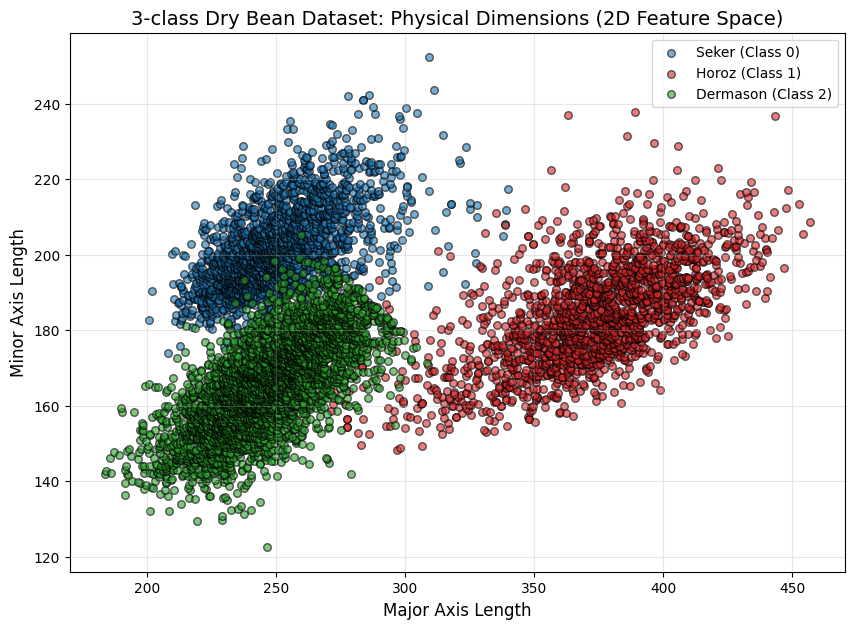

Train size: 5250 // Val size: 1125 // Test size: 1126


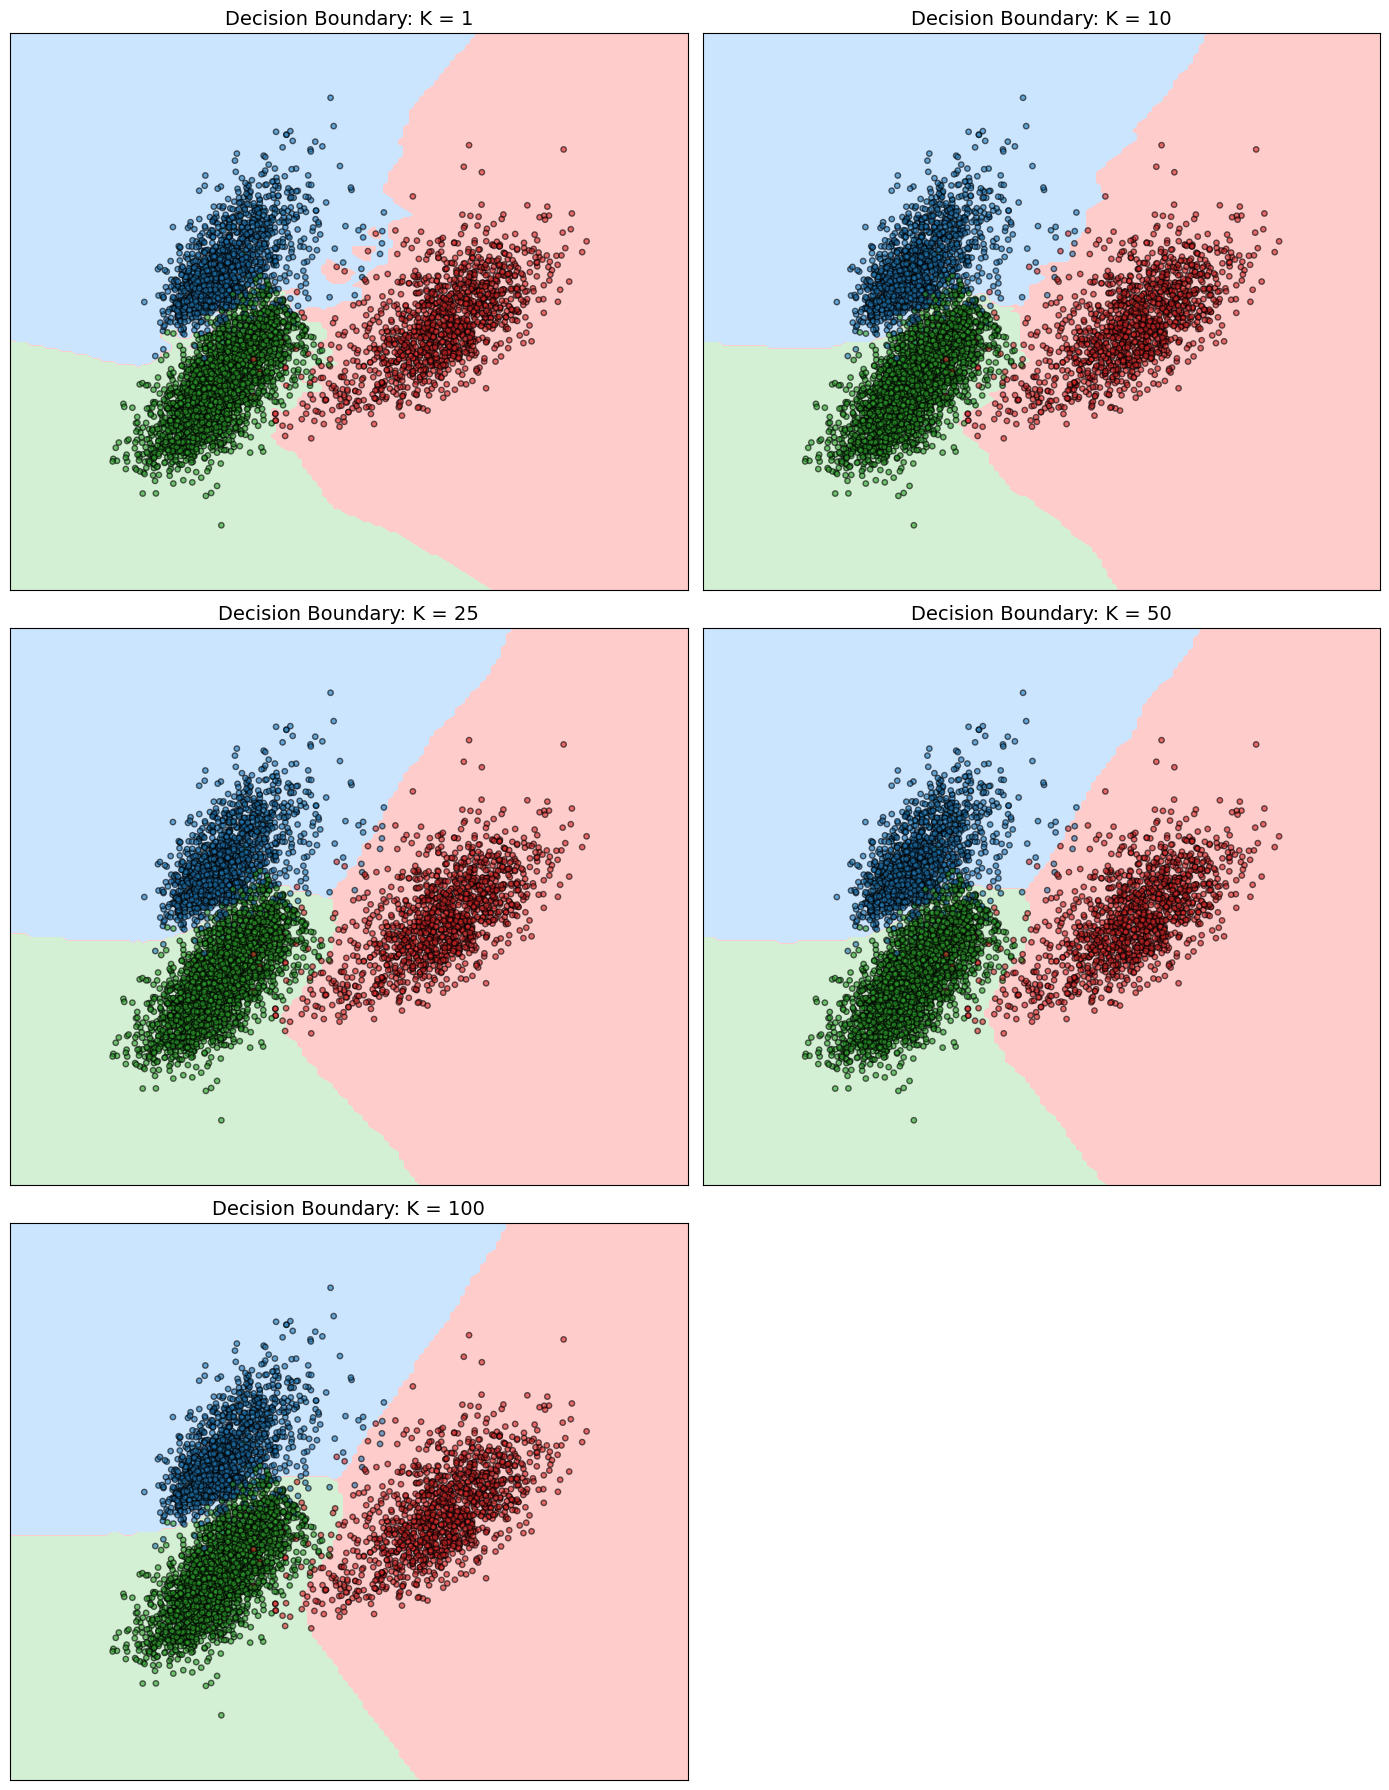


Optimal K value for the dataset 11


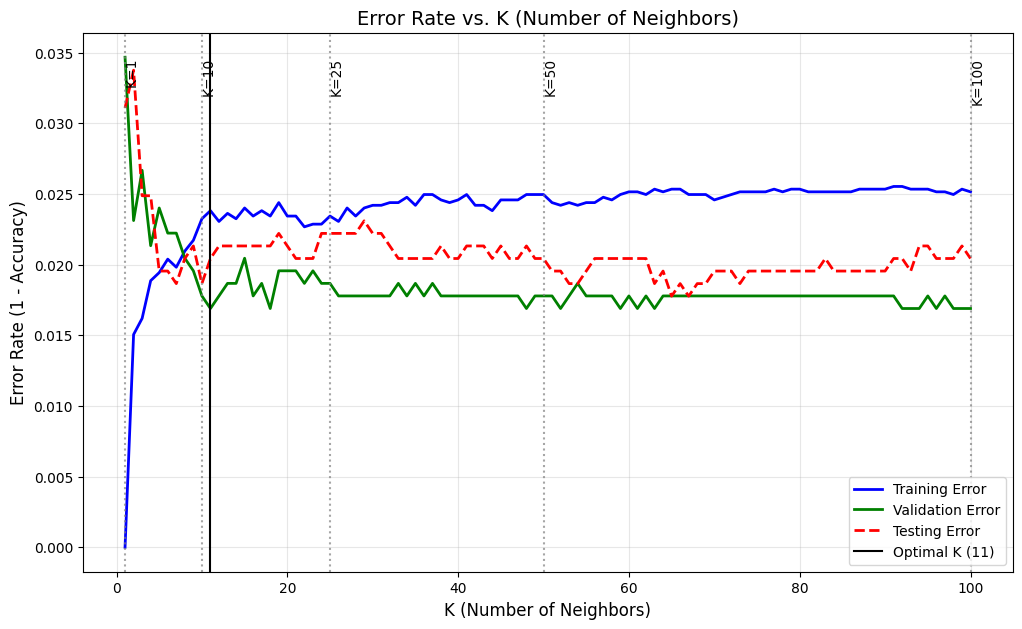

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from matplotlib.colors import ListedColormap
from sklearn.metrics import accuracy_score

# ==========================================
# PART 1: DATA LOADING & VISUALIZATION
# ==========================================

#Load Dry_Bean_Dataset.xlsx

df = pd.read_excel('Dry_Bean_Dataset.xlsx')

# OG dataset size
print(f"Original dataset size: {len(df)} rows")

# Clean the 'Class' column by removing hidden spaces and making it UPPERCASE
# This prevents 0-row filtering errors due to messy raw data strings

df['Class'] = df['Class'].astype(str).str.strip().str.upper()

# The original dataset has 7 classes. We filter it down to exactly 3 classes

df = df[df['Class'].isin(['SEKER', 'HOROZ', 'DERMASON'])]

print(f"Dataset size after filtering to 3 classes: {len(df)} rows")

# Map the 3 chosen species to integers (0, 1, 2)
class_map = {'SEKER': 0, 'HOROZ': 1, 'DERMASON': 2}
df['class_encoded'] = df['Class'].map(class_map)


# We extract two physical dimensions for the 2D spatial map
# Feature 1: MajorAxisLength (Length of the bean)
# Feature 2: MinorAxisLength (Width of the bean)
X = df[['MajorAxisLength', 'MinorAxisLength']].values
y = df['class_encoded'].values

# Plotting the raw dataset
plt.figure(figsize=(10, 7))

# Scatter plot for each class
classes = ['Seker (Class 0)', 'Horoz (Class 1)', 'Dermason (Class 2)']
colors = ['#1f77b4', '#d62728', '#2ca02c'] # Blue, Red, Green

for i in range(3):
    plt.scatter(
        X[y == i, 0], X[y == i, 1],
        c=colors[i], label=classes[i],
        alpha=0.6, edgecolors='k', s=30
    )


plt.title('3-class Dry Bean Dataset: Physical Dimensions (2D Feature Space)', fontsize=14)
plt.xlabel('Major Axis Length', fontsize=12)
plt.ylabel('Minor Axis Length', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# ==========================================
# PART 2: PREPROCESSING & DATA SPLITTING
# ==========================================


# Splitting the filtered points into Train (70%), Validation (15%), and Testing (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
     # stratify = y -> ensures exact ratio of the classes is preserved
     # across all three splits.
)


X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=(0.15/0.85), random_state=42, stratify=y_temp
)


print(f"Train size: {len(X_train)} // Val size: {len(X_val)} // Test size: {len(X_test)}")

# Scaling prevents features with larger values from dominating the Euclidean distance.
scaler = StandardScaler()


# Fit the scaler only on the training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation and test sets using the rules learned from the training set
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


# ==========================================
# PART 3: VISUALIZING DECISION BOUNDARIES
# ==========================================

# Low values for K (K=1 or K=2) can be noisy and subject to the effects of outliers
# Large values for K smooth over things, but there is a possiblity that a category
# with only few samples in it will always be voted out by other categories

k_values = [1, 10, 25, 50, 100]


# Setup the color maps for the plot (Light colors for background, dark for points)
cmap_light = ListedColormap(['#cce5ff', '#ffcccc', '#d4f0d4']) # Light Blue, Light Red, Light Green
cmap_bold = ListedColormap(['#1f77b4', '#d62728', '#2ca02c'])  # Dark Blue, Dark Red, Dark Green


# 1. Create the Meshgrid
# We create a dense grid of points covering the entire feature space.
h = 0.05  # Step size of the grid
x_min, x_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
y_min, y_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))



plt.figure(figsize=(14, 18))

# 2. Train and Plot for each K
for i, k in enumerate(k_values):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    # Predict the class for every single point on our grid
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # 3 rows, 2 columns grid arrangement for larger plots
    ax = plt.subplot(3, 2, i + 1)
    ax.contourf(xx, yy, Z, cmap=cmap_light)

    # Overlay the actual training points on top
    ax.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, cmap=cmap_bold,
               edgecolor='k', s=15, alpha=0.6)

    ax.set_title(f"Decision Boundary: K = {k}", fontsize=14)
    ax.set_xticks(())
    ax.set_yticks(())



plt.tight_layout()
plt.show()


# ==========================================
# PART 4: ERROR ANALYSIS
# ==========================================

# Testing every single K from 1 to 100
k_sweep = range(1, 101)
train_errors = []
val_errors = []
test_errors = []

for k in k_sweep:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    # Calculate Error Rate (1 - Accuracy)
    train_err = 1 - accuracy_score(y_train, knn.predict(X_train_scaled))
    val_err = 1 - accuracy_score(y_val, knn.predict(X_val_scaled))
    test_err = 1 - accuracy_score(y_test, knn.predict(X_test_scaled))

    train_errors.append(train_err)
    val_errors.append(val_err)
    test_errors.append(test_err)

# Find the optimal K (the one with the lowest validation error)
best_k = k_sweep[np.argmin(val_errors)]


plt.figure(figsize=(12, 7))

plt.plot(k_sweep, train_errors, label='Training Error', color='blue', lw=2)
plt.plot(k_sweep, val_errors, label='Validation Error', color='green', lw=2)
plt.plot(k_sweep, test_errors, label='Testing Error', color='red', linestyle='--', lw=2)

# Highlight the 5 specific K values plotted boundaries for earlier
k_markers = [1, 10, 25, 50, 100]
for mk in k_markers:
    plt.axvline(x=mk, color='gray', linestyle=':', alpha=0.7)
    plt.text(mk, max(val_errors), f'K={mk}', rotation=90, verticalalignment='top')

# Highlight the best K
plt.axvline(x=best_k, color='black', linestyle='-', label=f'Optimal K ({best_k})')


plt.title('Error Rate vs. K (Number of Neighbors)', fontsize=14)
plt.xlabel('K (Number of Neighbors)', fontsize=12)
plt.ylabel('Error Rate (1 - Accuracy)', fontsize=12)

plt.legend()
plt.grid(True, alpha=0.3)
print()
print(f"Optimal K value for the dataset {best_k}")
plt.show()